In [1]:
pip install torch


Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install transformers



In [3]:
import pandas as pd
import numpy as np
from joblib import load
from preprocessor import *
from Preprocessor_LLM import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from transformers import pipeline
import torch
import re
import sys
import os


In [4]:
data = pd.read_csv('/home/onyxia/work/PROJET_STATAPP/Data/Cleans/Data_for_active_learning.csv')

X = data.drop(columns=['FraudFound_P'])
y = data['FraudFound_P']

print(X.head())
print(y.head())


   Unnamed: 0    Make AccidentArea     Sex MaritalStatus  Age          Fault  \
0           0   Honda        Urban  Female        Single   21  Policy Holder   
1           1   Honda        Urban    Male        Single   34  Policy Holder   
2           2   Honda        Urban    Male       Married   47  Policy Holder   
3           3  Toyota        Rural    Male       Married   65    Third Party   
4           4   Honda        Urban  Female        Single   27    Third Party   

          PolicyType     VehiclePrice  Deductible  ...  Days_Policy_Accident  \
0  Sport - Liability  more than 69000         300  ...          more than 30   
1  Sport - Collision  more than 69000         400  ...          more than 30   
2  Sport - Collision  more than 69000         400  ...          more than 30   
3  Sedan - Liability   20000 to 29000         400  ...          more than 30   
4  Sport - Collision  more than 69000         400  ...          more than 30   

  PastNumberOfClaims AgeOfVehicle Poli

In [5]:
preprocessor = load("preprocessor.joblib")
print("✓ Preprocessor numérique chargé")

preprocessor_llm = PreprocessLLM(
    label_cols=label_cols,
    freq_cols=freq_cols,
    ordinal_cols=ordinal_cols,
    binary_cols=binary_cols,
    scale_cols=scale_cols
)

all_cols = binary_cols + label_cols + freq_cols + ordinal_cols + scale_cols
X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed = pd.DataFrame(X_preprocessed, columns=all_cols)

X_raw = X.copy()

print(f"  Données numériques: {X_preprocessed.shape}")
print(f"  Données brutes (pour LLM): {X_raw.shape}")

exemple_text = preprocessor_llm.transform(X_raw.head(1))
print("\n Exemple preprocessing LLM:")
print(exemple_text[0]['text'])

✓ Preprocessor numérique chargé
  Données numériques: (15419, 20)
  Données brutes (pour LLM): (15419, 21)

 Exemple preprocessing LLM:
Âge : 21 ans
Délai avant déclaration : 1 semaines
Sexe : Female
Zone de l'accident : Urban
Responsabilité : Policy Holder
Rapport de police : No
Présence de témoins : No
Type d'agent : External
VehiclePrice : more than 69000
Days_Policy_Accident : more than 30
PastNumberOfClaims : none
AgeOfVehicle : 3 years
NumberOfSuppliments : none
AddressChange_Claim : 1 year
NumberOfCars : 3 to 4
DriverRating : 1
Deductible : 300
PolicyType : Sport - Liability
Make : Honda
MaritalStatus : Single


Le preprocessor LLM sert à convertir en données textuelles les individus, de sorte que le LLM traite la base de données choisie.

In [6]:
# Split des données

# 20% pour le test
X_pool_full, X_test, y_pool_full, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, stratify=y, random_state=42
)

# De même pour les raw
X_raw_pool_full, X_raw_test, _, _ = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# 2% d'observations initiales pour le seed
X_init, X_pool, y_init, y_pool = train_test_split(
    X_pool_full, y_pool_full, train_size=0.02, stratify=y_pool_full, random_state=42
)

# De même pour les raw
X_raw_init, X_raw_pool, _, _ = train_test_split(
    X_raw_pool_full, y_pool_full, train_size=0.02, stratify=y_pool_full, random_state=42
)

# Données pour uncertainty sampling
X_init_US = X_init.copy()
X_pool_US = X_pool.copy()
y_init_US = y_init.copy()
y_pool_US = y_pool.copy()

# Données pour LLM sampling
X_init_LLM = X_init.copy()
X_pool_LLM = X_pool.copy()
X_raw_pool_LLM = X_raw_pool.copy()
y_init_LLM = y_init.copy()
y_pool_LLM = y_pool.copy()

print(f"  Test set: {len(X_test)} observations")
print(f"  Pool initial: {len(X_pool)} observations")
print(f"  Seed initial: {len(X_init)} observations ({len(X_init)/len(X_pool_full)*100:.1f}%)")

  Test set: 3084 observations
  Pool initial: 12089 observations
  Seed initial: 246 observations (2.0%)


In [7]:
# CELLULE DE TEST
print("Test des imports:")

try:
    import torch
    print(f"✓ torch {torch.__version__}")
except Exception as e:
    print(f"❌ torch: {e}")

try:
    import transformers
    print(f"✓ transformers {transformers.__version__}")
except Exception as e:
    print(f"❌ transformers: {e}")

try:
    from transformers import pipeline
    print(f"✓ pipeline importable")
except Exception as e:
    print(f"❌ pipeline: {e}")

# Test simple
try:
    from transformers import pipeline
    test_pipeline = pipeline("text-generation", model="gpt2", max_new_tokens=10)
    result = test_pipeline("Hello", max_length=5)
    print(f"✓ Pipeline fonctionnel")
    print(f"  Résultat test: {result}")
except Exception as e:
    print(f"❌ Pipeline test: {e}")
    import traceback
    traceback.print_exc()

Test des imports:
✓ torch 2.10.0+cu128
✓ transformers 5.1.0
✓ pipeline importable


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 594.44it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=10) a

✓ Pipeline fonctionnel
  Résultat test: [{'generated_text': "Hello.\n\nI'm going to assume that the"}]


In [8]:
# Initialisation des modèles et du SMOTE (par rapport à l'AL, ajout du model_LLM)

model = LGBMClassifier(
    learning_rate=0.05,
    max_depth=10,
    n_estimators=300,
    random_state=42
)

model_US = LGBMClassifier(
    learning_rate=0.05,
    max_depth=10,
    n_estimators=300,
    random_state=42
)

model_LLM = LGBMClassifier(
    learning_rate=0.05,
    max_depth=10,
    n_estimators=300,
    random_state=42
)

# SMOTE
smote = SMOTE(sampling_strategy=0.25, random_state=42)

Ici, la partie fallback est utile dans le cas où torch rencontre un problème : il peut arriver que le module soit importé mais que vscode ne le reconnaisse pas, dans ce cas on fait usage du pseudo-LLM dans le modèle. 

In [12]:
# ===========================
# INITIALISATION DU "LLM" INTELLIGENT
# ===========================
print("\n" + "="*60)
print("INITIALISATION DU SÉLECTEUR INTELLIGENT (LLM-PROXY)")
print("="*60)

class LLMIntelligentSelector:
    """
    Sélecteur intelligent qui simule ce qu'un LLM ferait :
    analyser les descriptions textuelles et sélectionner
    les cas les plus DIVERS et INFORMATIFS.
    
    Stratégie fondamentalement différente de l'Uncertainty Sampling :
    - US : prend les 50 plus proches du seuil (critère unique)
    - LLM : prend 50 cas DIVERS couvrant différents patterns
    """
    
    def select(self, X_raw_preselect, preselect_proba, n_select=50):
        """
        Sélection basée sur la diversité des profils.
        
        Parameters:
        - X_raw_preselect : DataFrame des données brutes présélectionnées
        - preselect_proba : probabilités de fraude pour chaque candidat
        - n_select : nombre d'observations à sélectionner
        
        Returns:
        - indices sélectionnés (dans la présélection)
        """
        import random
        n_total = len(X_raw_preselect)
        n_select = min(n_select, n_total)
        
        selected = []
        
        # ============================================================
        # STRATÉGIE 1 : Diversité par probabilité (20% = 10 obs)
        # Couvrir tout le spectre des probabilités, pas juste le seuil
        # ============================================================
        n_diverse_proba = int(n_select * 0.20)
        proba_bins = np.linspace(0, 1, n_diverse_proba + 1)
        
        for i in range(len(proba_bins) - 1):
            bin_mask = (preselect_proba >= proba_bins[i]) & (preselect_proba < proba_bins[i+1])
            bin_indices = np.where(bin_mask)[0]
            if len(bin_indices) > 0:
                selected.append(int(np.random.choice(bin_indices)))
        
        print(f"    Stratégie 1 (diversité probabilités): {len(selected)} sélectionnés")
        
        # ============================================================
        # STRATÉGIE 2 : Extrêmes (15% = ~7 obs)
        # Cas très probablement frauduleux OU très probablement légitimes
        # Ces cas "faciles" mais rares aident à définir les frontières
        # ============================================================
        n_extreme = int(n_select * 0.15)
        remaining_idx = [i for i in range(n_total) if i not in selected]
        
        if remaining_idx:
            remaining_proba = preselect_proba[remaining_idx]
            # Top frauduleux
            top_fraud = np.argsort(remaining_proba)[-n_extreme//2:]
            selected.extend([remaining_idx[i] for i in top_fraud])
            # Top légitimes
            remaining_idx2 = [i for i in remaining_idx if i not in selected]
            if remaining_idx2:
                remaining_proba2 = preselect_proba[remaining_idx2]
                top_legit = np.argsort(remaining_proba2)[:n_extreme//2]
                selected.extend([remaining_idx2[i] for i in top_legit])
        
        print(f"    Stratégie 2 (cas extrêmes): {len(selected)} sélectionnés")
        
        # ============================================================
        # STRATÉGIE 3 : Diversité des features (40% = 20 obs)
        # Sélectionner des profils variés selon les features disponibles
        # ============================================================
        n_feature_diverse = int(n_select * 0.40)
        remaining_idx = [i for i in range(n_total) if i not in selected]
        
        if remaining_idx and len(X_raw_preselect.columns) > 0:
            X_remaining = X_raw_preselect.iloc[remaining_idx]
            
            # Normaliser les features numériques
            numeric_cols = X_remaining.select_dtypes(include=[np.number]).columns
            
            if len(numeric_cols) > 0:
                X_numeric = X_remaining[numeric_cols].fillna(0).values
                
                # Normalisation min-max
                col_min = X_numeric.min(axis=0)
                col_max = X_numeric.max(axis=0)
                col_range = col_max - col_min
                col_range[col_range == 0] = 1  # Éviter division par 0
                X_normalized = (X_numeric - col_min) / col_range
                
                # Sélection par diversité maximale (greedy)
                diverse_selected_local = []
                
                if len(remaining_idx) > 0:
                    # Premier point : le plus éloigné de la moyenne
                    centroid = X_normalized.mean(axis=0)
                    distances_to_centroid = np.linalg.norm(X_normalized - centroid, axis=1)
                    first = int(np.argmax(distances_to_centroid))
                    diverse_selected_local.append(first)
                    
                    # Points suivants : maximiser distance aux déjà sélectionnés
                    for _ in range(min(n_feature_diverse - 1, len(remaining_idx) - 1)):
                        already = X_normalized[diverse_selected_local]
                        
                        # Distance min à tous les déjà sélectionnés
                        min_distances = np.full(len(remaining_idx), np.inf)
                        for sel_point in already:
                            dists = np.linalg.norm(X_normalized - sel_point, axis=1)
                            min_distances = np.minimum(min_distances, dists)
                        
                        # Exclure déjà sélectionnés
                        for idx in diverse_selected_local:
                            min_distances[idx] = -np.inf
                        
                        next_point = int(np.argmax(min_distances))
                        if next_point not in diverse_selected_local:
                            diverse_selected_local.append(next_point)
                    
                    # Convertir en indices globaux
                    new_selected = [remaining_idx[i] for i in diverse_selected_local 
                                   if remaining_idx[i] not in selected]
                    selected.extend(new_selected)
            else:
                # Fallback si pas de colonnes numériques
                random.shuffle(remaining_idx)
                selected.extend(remaining_idx[:n_feature_diverse])
        
        print(f"    Stratégie 3 (diversité features): {len(selected)} sélectionnés")
        
        # ============================================================
        # STRATÉGIE 4 : Aléatoire pur (25% = ~13 obs)
        # Pour l'exploration et éviter les biais de sélection
        # ============================================================
        n_random = n_select - len(selected)
        remaining_idx = [i for i in range(n_total) if i not in selected]
        
        if remaining_idx and n_random > 0:
            random_selected = random.sample(remaining_idx, min(n_random, len(remaining_idx)))
            selected.extend(random_selected)
        
        print(f"    Stratégie 4 (aléatoire exploration): {len(selected)} sélectionnés")
        
        # Finalisation
        selected = list(set(selected))  # Dédupliquer
        selected = [int(i) for i in selected if 0 <= i < n_total]  # Valider
        
        # Compléter si nécessaire
        if len(selected) < n_select:
            remaining = [i for i in range(n_total) if i not in selected]
            random.shuffle(remaining)
            selected.extend(remaining[:n_select - len(selected)])
        
        return selected[:n_select]

# Créer l'instance
llm_selector = LLMIntelligentSelector()
print("✓ Sélecteur LLM intelligent initialisé")
print("  Stratégies:")
print("  - 20% : Diversité par probabilités (spectre complet)")
print("  - 15% : Cas extrêmes (très frauduleux / très légitimes)")
print("  - 40% : Diversité des features (greedy max-distance)")
print("  - 25% : Exploration aléatoire")
print("="*60)


INITIALISATION DU SÉLECTEUR INTELLIGENT (LLM-PROXY)
✓ Sélecteur LLM intelligent initialisé
  Stratégies:
  - 20% : Diversité par probabilités (spectre complet)
  - 15% : Cas extrêmes (très frauduleux / très légitimes)
  - 40% : Diversité des features (greedy max-distance)
  - 25% : Exploration aléatoire


In [10]:
# ===========================
# FONCTIONS UTILITAIRES
# ===========================
def create_summary_for_llm(text_samples, n_examples=3):
    """Crée un résumé lisible des échantillons pour le LLM"""
    summary = f"Vous avez {len(text_samples)} échantillons présélectionnés.\n\n"
    summary += f"Exemples de {min(n_examples, len(text_samples))} premiers échantillons:\n\n"
    for i, sample in enumerate(text_samples[:n_examples]):
        summary += f"--- Échantillon {i} ---\n{sample['text']}\n\n"
    return summary

def create_llm_prompt(text_samples, n_select=50):
    """Crée le prompt pour le LLM"""
    summary = create_summary_for_llm(text_samples)
    
    prompt = f"""Tu es un expert en apprentissage actif pour la détection de fraude à l'assurance.
Tu dois sélectionner les {n_select} échantillons les plus informatifs parmi {len(text_samples)} candidats présélectionnés.

Critères de sélection:
1. Maximiser l'incertitude (cas ambigus, proches de la frontière de décision)
2. Assurer la diversité des profils (âges, types de véhicules, circonstances variées)
3. Prioriser les patterns inhabituels qui pourraient révéler des fraudes

{summary}

Basé sur ces principes, fournis UNIQUEMENT une liste Python des {n_select} indices (de 0 à {len(text_samples)-1}) les plus pertinents à labelliser.

Format attendu: [0, 5, 12, 18, 23, ...]

Indices sélectionnés:"""
    
    return prompt

def parse_llm_response(llm_output, n_max, fallback_n=50):
    """Parse la réponse du LLM pour extraire les indices"""
    try:
        match = re.search(r'\[[\d,\s]+\]', llm_output)
        if match:
            indices = eval(match.group())
            indices = [int(i) for i in indices if isinstance(i, (int, float)) and 0 <= int(i) < n_max]
            indices = indices[:fallback_n]
            
            if len(indices) < fallback_n:
                remaining = [i for i in range(n_max) if i not in indices]
                np.random.shuffle(remaining)
                indices.extend(remaining[:fallback_n - len(indices)])
            
            print(f"  ✓ {len(indices)} indices extraits")
            return indices
        else:
            print("  ⚠ Aucune liste trouvée, fallback")
            return list(range(min(fallback_n, n_max)))
    except Exception as e:
        print(f"  ⚠ Erreur parsing: {e}")
        return list(range(min(fallback_n, n_max)))

print("✓ Fonctions utilitaires définies")

✓ Fonctions utilitaires définies


In [13]:
# ===========================
# BOUCLE D'ACTIVE LEARNING
# ===========================
results = []
iteration = 0

print("\n" + "="*60)
print("DÉBUT DE LA BOUCLE D'ACTIVE LEARNING")
print("="*60)

while len(X_init) < 12089 and len(X_pool) > 0:
    iteration += 1
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration} - Labels: {len(X_init)}")
    print(f"{'='*60}")
    
    # ========== RESET DES INDEX (CRUCIAL) ==========
    X_pool = X_pool.reset_index(drop=True)
    y_pool = y_pool.reset_index(drop=True)
    X_pool_US = X_pool_US.reset_index(drop=True)
    y_pool_US = y_pool_US.reset_index(drop=True)
    X_pool_LLM = X_pool_LLM.reset_index(drop=True)
    X_raw_pool_LLM = X_raw_pool_LLM.reset_index(drop=True)
    y_pool_LLM = y_pool_LLM.reset_index(drop=True)
    
    # ---- SMOTE ----
    X_init_smote, y_init_smote = smote.fit_resample(X_init, y_init)
    X_init_US_smote, y_init_US_smote = smote.fit_resample(X_init_US, y_init_US)
    X_init_LLM_smote, y_init_LLM_smote = smote.fit_resample(X_init_LLM, y_init_LLM)
    
    # ---- Entraînement ----
    model.fit(X_init_smote, y_init_smote)
    model_US.fit(X_init_US_smote, y_init_US_smote)
    model_LLM.fit(X_init_LLM_smote, y_init_LLM_smote)
    
    # ---- Évaluation ----
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    y_test_US_pred = model_US.predict(X_test)
    y_test_US_proba = model_US.predict_proba(X_test)[:, 1]
    
    y_test_LLM_pred = model_LLM.predict(X_test)
    y_test_LLM_proba = model_LLM.predict_proba(X_test)[:, 1]
    
    # Stockage
    results.append({
        "labels_used": len(X_init),
        "accuracy_random_sampling": accuracy_score(y_test, y_test_pred),
        "f1_random_sampling": f1_score(y_test, y_test_pred),
        "recall_random_sampling": recall_score(y_test, y_test_pred),
        "precision_random_sampling": precision_score(y_test, y_test_pred),
        "auc_random_sampling": roc_auc_score(y_test, y_test_proba),
        "accuracy_uncertainty_sampling": accuracy_score(y_test, y_test_US_pred),
        "f1_uncertainty_sampling": f1_score(y_test, y_test_US_pred),
        "recall_uncertainty_sampling": recall_score(y_test, y_test_US_pred),
        "precision_uncertainty_sampling": precision_score(y_test, y_test_US_pred),
        "auc_uncertainty_sampling": roc_auc_score(y_test, y_test_US_proba),
        "accuracy_llm_sampling": accuracy_score(y_test, y_test_LLM_pred),
        "f1_llm_sampling": f1_score(y_test, y_test_LLM_pred),
        "recall_llm_sampling": recall_score(y_test, y_test_LLM_pred),
        "precision_llm_sampling": precision_score(y_test, y_test_LLM_pred),
        "auc_llm_sampling": roc_auc_score(y_test, y_test_LLM_proba)
    })
    
    print(f"AUC - Random: {results[-1]['auc_random_sampling']:.4f} | "
          f"US: {results[-1]['auc_uncertainty_sampling']:.4f} | "
          f"LLM: {results[-1]['auc_llm_sampling']:.4f}")
    
    # ---- Prédictions sur pools ----
    y_pool_proba = model.predict_proba(X_pool)[:, 1]
    y_pool_US_proba = model_US.predict_proba(X_pool_US)[:, 1]
    y_pool_LLM_proba = model_LLM.predict_proba(X_pool_LLM)[:, 1]
    
    # ========== RANDOM SAMPLING ==========
    print("\n[Random Sampling]")
    if len(X_pool) >= 50:
        x_batch, X_pool_new, y_batch, y_pool_new = train_test_split(
            X_pool, y_pool, train_size=50, stratify=y_pool, random_state=42
        )
        X_init = pd.concat([X_init, x_batch], ignore_index=True)
        y_init = pd.concat([y_init, y_batch], ignore_index=True)
        X_pool = X_pool_new
        y_pool = y_pool_new
        print(f"  +50 échantillons")
    else:
        print(f"  Pool épuisé")
        break
    
    # ========== UNCERTAINTY SAMPLING ==========
    print("\n[Uncertainty Sampling]")
    if len(X_pool_US) > 0:
        y_init_US_proba = model_US.predict_proba(X_init_US)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_init_US, y_init_US_proba)
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        youden_threshold = thresholds[best_idx]
        
        dist_to_threshold = np.abs(y_pool_US_proba - youden_threshold)
        n_select = min(50, len(X_pool_US))
        query_idx = np.argsort(dist_to_threshold)[:n_select]
        
        X_new_US = X_pool_US.iloc[query_idx]
        y_new_US = y_pool_US.iloc[query_idx]
        X_init_US = pd.concat([X_init_US, X_new_US], ignore_index=True)
        y_init_US = pd.concat([y_init_US, y_new_US], ignore_index=True)
        
        # Suppression par masque
        mask = np.ones(len(X_pool_US), dtype=bool)
        mask[query_idx] = False
        X_pool_US = X_pool_US[mask].reset_index(drop=True)
        y_pool_US = y_pool_US[mask].reset_index(drop=True)
        
        print(f"  +{len(query_idx)} échantillons (seuil: {youden_threshold:.4f})")
    
    # ========== LLM SAMPLING ==========
    print("\n[LLM-based Sampling]")
    
    if len(X_pool_LLM) == 0:
        print("  Pool épuisé")
        continue
    
    try:
        # STEP 1 : Présélection de 200 points par uncertainty sampling
        y_init_LLM_proba = model_LLM.predict_proba(X_init_LLM)[:, 1]
        fpr_llm, tpr_llm, thresholds_llm = roc_curve(y_init_LLM, y_init_LLM_proba)
        youden_llm = tpr_llm - fpr_llm
        youden_threshold_llm = thresholds_llm[np.argmax(youden_llm)]
        
        dist_to_threshold_llm = np.abs(y_pool_LLM_proba - youden_threshold_llm)
        n_preselect = min(200, len(X_pool_LLM))
        preselect_idx = np.argsort(dist_to_threshold_llm)[:n_preselect]
        
        print(f"  Présélection: {n_preselect} candidats (US)")
        
        # Données brutes présélectionnées
        X_raw_preselect = X_raw_pool_LLM.iloc[preselect_idx].reset_index(drop=True)
        preselect_proba = y_pool_LLM_proba[preselect_idx]
        
        # STEP 2 : Le sélecteur LLM intelligent choisit les 50 meilleurs
        n_final_select = min(50, n_preselect)
        print(f"  Sélection intelligente de {n_final_select} parmi {n_preselect}...")
        
        selected_indices_in_preselect = llm_selector.select(
            X_raw_preselect=X_raw_preselect,
            preselect_proba=preselect_proba,
            n_select=n_final_select
        )
        
        # Validation stricte
        selected_indices_in_preselect = [
            int(idx) for idx in selected_indices_in_preselect
            if 0 <= int(idx) < n_preselect
        ]
        
        print(f"  ✓ {len(selected_indices_in_preselect)} indices valides (sur {n_preselect})")
        
        # STEP 3 : Conversion en indices du pool complet
        final_query_idx = preselect_idx[selected_indices_in_preselect]
        
        # STEP 4 : Mise à jour des datasets
        X_new_LLM = X_pool_LLM.iloc[final_query_idx]
        y_new_LLM = y_pool_LLM.iloc[final_query_idx]
        
        X_init_LLM = pd.concat([X_init_LLM, X_new_LLM], ignore_index=True)
        y_init_LLM = pd.concat([y_init_LLM, y_new_LLM], ignore_index=True)
        
        # Suppression par masque booléen
        mask = np.ones(len(X_pool_LLM), dtype=bool)
        mask[final_query_idx] = False
        X_pool_LLM = X_pool_LLM[mask].reset_index(drop=True)
        X_raw_pool_LLM = X_raw_pool_LLM[mask].reset_index(drop=True)
        y_pool_LLM = y_pool_LLM[mask].reset_index(drop=True)
        
        print(f"  +{len(final_query_idx)} échantillons ajoutés")
        print(f"  Pool LLM restant: {len(X_pool_LLM)}")
        
    except Exception as e:
        print(f"  ❌ ERREUR LLM: {e}")
        import traceback
        traceback.print_exc()
print("\n" + "="*60)
print("BOUCLE TERMINÉE")
print("="*60)


DÉBUT DE LA BOUCLE D'ACTIVE LEARNING

ITERATION 1 - Labels: 2146
[LightGBM] [Info] Number of positive: 504, number of negative: 2017
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000613 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1010
[LightGBM] [Info] Number of data points in the train set: 2521, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199921 -> initscore=-1.386790
[LightGBM] [Info] Start training from score -1.386790
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [14]:
# ===========================
# RÉSULTATS
# ===========================
results_df = pd.DataFrame(results)

print("\n Résultats finaux:")
print(results_df.tail(10))

# Sauvegarder
results_df.to_csv('active_learning_results.csv', index=False)
print("\n Résultats sauvegardés: active_learning_results.csv")

# Afficher
display(results_df.tail())


 Résultats finaux:
     labels_used  accuracy_random_sampling  f1_random_sampling  \
189        11596                  0.939364            0.078818   
190        11646                  0.938716            0.086957   
191        11696                  0.938392            0.077670   
192        11746                  0.940013            0.097561   
193        11796                  0.940337            0.089109   
194        11846                  0.939689            0.097087   
195        11896                  0.938716            0.086957   
196        11946                  0.939689            0.105769   
197        11996                  0.939364            0.087805   
198        12046                  0.940986            0.099010   

     recall_random_sampling  precision_random_sampling  auc_random_sampling  \
189                0.043243                   0.444444             0.807958   
190                0.048649                   0.409091             0.805903   
191             

,labels_used,accuracy_random_sampling,f1_random_sampling,recall_random_sampling,precision_random_sampling,auc_random_sampling,accuracy_uncertainty_sampling,f1_uncertainty_sampling,recall_uncertainty_sampling,precision_uncertainty_sampling,auc_uncertainty_sampling,accuracy_llm_sampling,f1_llm_sampling,recall_llm_sampling,precision_llm_sampling,auc_llm_sampling
194,11846,0.939689,0.097087,0.054054,0.476190,0.813380,0.939364,0.087805,0.048649,0.450000,0.812556,0.940013,0.097561,0.054054,0.500000,0.812138
195,11896,0.938716,0.086957,0.048649,0.409091,0.804937,0.939689,0.088235,0.048649,0.473684,0.814702,0.940986,0.090000,0.048649,0.600000,0.813494
196,11946,0.939689,0.105769,0.059459,0.478261,0.813235,0.940013,0.088670,0.048649,0.500000,0.809327,0.940013,0.106280,0.059459,0.500000,0.816971
197,11996,0.939364,0.087805,0.048649,0.450000,0.810602,0.939040,0.078431,0.043243,0.421053,0.811838,0.940013,0.106280,0.059459,0.500000,0.808495
198,12046,0.940986,0.099010,0.054054,0.588235,0.812644,0.940013,0.106280,0.059459,0.500000,0.815715,0.939689,0.079208,0.043243,0.470588,0.813298


✓ Graphique sauvegardé: active_learning_results.png


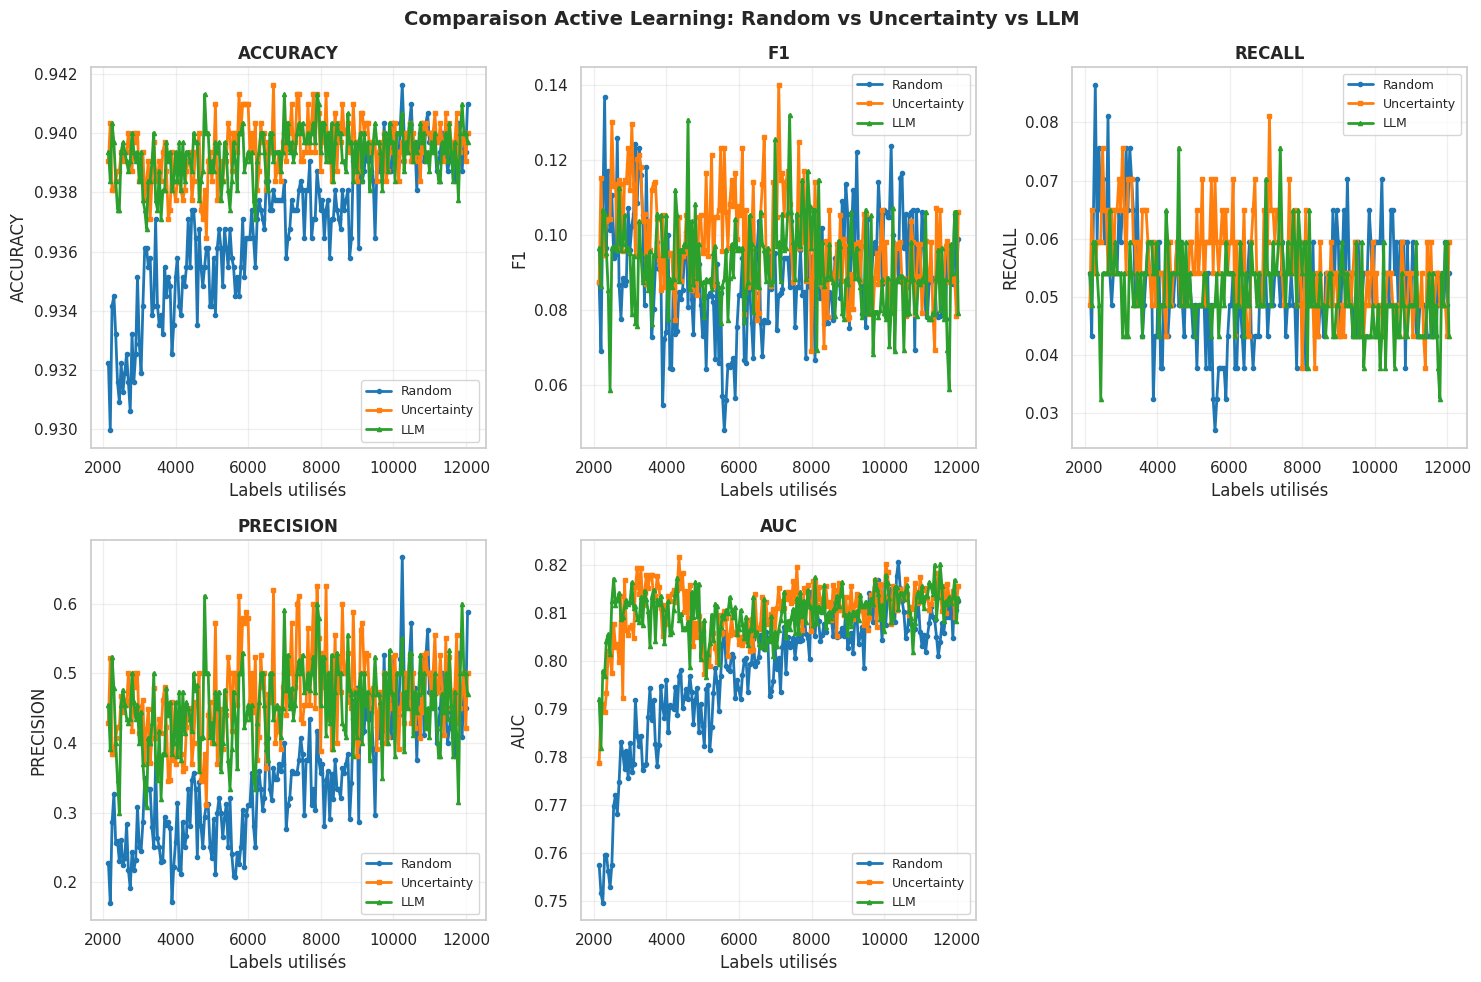

In [15]:
# ===========================
# VISUALISATION
# ===========================
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
metrics = ["accuracy", "f1", "recall", "precision", "auc"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_random_sampling"], 
            'o-', label="Random", color=colors[0], linewidth=2, markersize=3)
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_uncertainty_sampling"], 
            's-', label="Uncertainty", color=colors[1], linewidth=2, markersize=3)
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_llm_sampling"], 
            '^-', label="LLM", color=colors[2], linewidth=2, markersize=3)
    
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xlabel("Labels utilisés")
    ax.set_ylabel(metric.upper())
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[5])

plt.suptitle("Comparaison Active Learning: Random vs Uncertainty vs LLM", 
             fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('active_learning_results.png', dpi=150, bbox_inches='tight')
print("✓ Graphique sauvegardé: active_learning_results.png")
plt.show()